In [2]:
#Para el entrenamiento
#pip install wandb

In [2]:
# Importar librerías
import re
from nltk.corpus import stopwords
import pandas as pd
import torch
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from transformers import DataCollatorWithPadding
from datasets import Dataset, DatasetDict
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
column_names = ['label', 'statement', 'subject', 'speaker', 'job_title', 'state', 'party',
                'barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts',
                'pants_on_fire_counts', 'context']

train_df = pd.read_csv("train.tsv", sep='\t', names=column_names).dropna(subset=["label", "statement"])
valid_df = pd.read_csv("valid.tsv", sep='\t', names=column_names).dropna(subset=["label", "statement"])
test_df = pd.read_csv("test.tsv", sep='\t', names=column_names).dropna(subset=["label", "statement"])

# Convertir etiquetas a binario
# 0 = falso, 1 = verdadero
true_labels = ['mostly-true', 'true']

def convertir_a_binario(label):
    return 1 if label in true_labels else 0

train_df['label'] = train_df['label'].apply(convertir_a_binario)
valid_df['label'] = valid_df['label'].apply(convertir_a_binario)
test_df['label'] = test_df['label'].apply(convertir_a_binario)

# Limpiar textos (sin eliminar stopwords)
def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r"http\S+", "", texto)
    texto = re.sub(r"[^a-zA-Z0-9\s]", "", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

for df in [train_df, valid_df, test_df]:
    df["statement"] = df["statement"].apply(limpiar_texto)

train_df["statement"].sample(5)

,statement
265.json,i dont describe your plan as amnesty in my ad ...
6819.json,one of the first states in the union to pass a...
7530.json,in the period from 2007 to 2011 the office of ...
10221.json,austin mayoral candidate steve adler admitted ...
4659.json,on letting occupy atlanta protesters stay in w...


In [6]:
#Convertir a formato dataset
train_ds = Dataset.from_pandas(train_df[['statement', 'label']], preserve_index=False)
valid_ds = Dataset.from_pandas(valid_df[['statement', 'label']], preserve_index=False)
test_ds = Dataset.from_pandas(test_df[['statement', 'label']], preserve_index=False)

dataset = DatasetDict({
    'train': train_ds,
    'validation': valid_ds,
    'test': test_ds
})

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize_function(example):
    return tokenizer(example["statement"], truncation=True)

tokenized_datasets = dataset.map(tokenize_function, batched=True)

model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    return {
        "accuracy": accuracy_score(p.label_ids, preds),
        "f1": f1_score(p.label_ids, preds, average="weighted")
    }

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    logging_dir="./logs",
    logging_steps=10,
)

# Desactivar WandB
os.environ["WANDB_DISABLED"] = "true"

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# Entrenamiento
trainer.train()

# Evaluación en test
metrics = trainer.evaluate(tokenized_datasets["test"])
print(metrics)

Map:   0%|          | 0/10240 [00:00<?, ? examples/s]

Map:   0%|          | 0/1284 [00:00<?, ? examples/s]

Map:   0%|          | 0/1267 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.649000,0.591919,0.685358,0.676902
2,0.513800,0.602255,0.664330,0.662042
3,0.426500,0.705212,0.654984,0.654231


{'eval_loss': 0.6098699569702148, 'eval_accuracy': 0.6621941594317285, 'eval_f1': 0.6501662019711517, 'eval_runtime': 3.4951, 'eval_samples_per_second': 362.505, 'eval_steps_per_second': 22.889, 'epoch': 3.0}


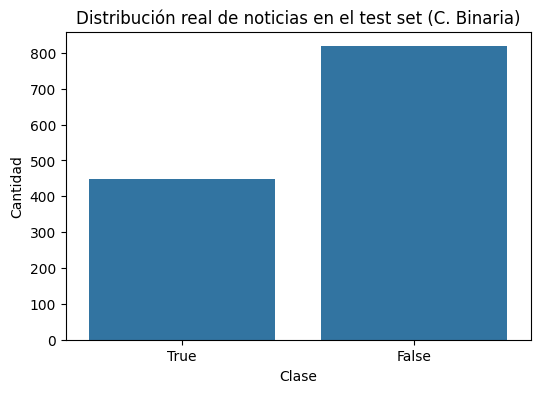

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

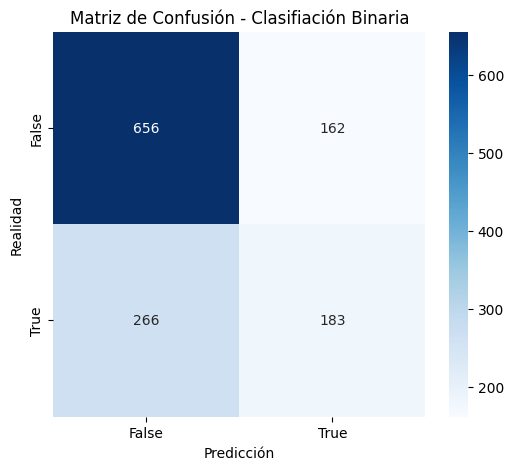

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Reporte de clasificación:

              precision    recall  f1-score   support

       False       0.71      0.80      0.75       818
        True       0.53      0.41      0.46       449

    accuracy                           0.66      1267
   macro avg       0.62      0.60      0.61      1267
weighted avg       0.65      0.66      0.65      1267



In [8]:
# Contar verdaderas y falsas en el test set
test_labels = test_df['label']

# Gráfico de barras
plt.figure(figsize=(6,4))
sns.countplot(x=test_labels.map({0: 'False', 1: 'True'}))
plt.title('Distribución real de noticias en el test set (C. Binaria)')
plt.xlabel('Clase')
plt.ylabel('Cantidad')
plt.show()

batch_size = 32
predictions = []

model.eval()

for i in range(0, len(test_df), batch_size):
    batch_texts = list(test_df['statement'].iloc[i:i+batch_size])
    inputs = tokenizer(batch_texts, return_tensors="pt", truncation=True, padding=True, max_length=512)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        batch_preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        predictions.extend(batch_preds)

predictions = np.array(predictions)


cm = confusion_matrix(test_labels, predictions)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["False", "True"], yticklabels=["False", "True"])
plt.title('Matriz de Confusión - Clasifiación Binaria')
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.show()

print("Reporte de clasificación:\n")
print(classification_report(test_labels, predictions, target_names=["False", "True"]))